<a href="https://colab.research.google.com/github/a-brhian/Design_Of_Experiments.pt/blob/main/01_Analise_de_Variancia_(ANOVA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#-------------------------------------------
# INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNOLOGIA DO AMAZONAS
#
# CREATED BY: ALYSSON BRHIAN DE SOUZA MUNIZ SILVA
# DATA: 04/03/2026
# VERSION OF R: 4.5.2
#
# GOAL: Analise de Variancia (ANOVA)
#
#---------------------------------------------

#Análise de Variância (ANOVA)

## Introdução ao problema

Uma indústria metalúrgica passou a produzir um novo tipo de peça de aço para atender a um cliente específico. Essas peças são fabricadas com um aço de baixa liga e, após o processo de usinagem, passam por um tratamento térmico conhecido como **têmpera**.

A têmpera é um processo em que o aço aquecido é resfriado rapidamente em um meio líquido, como **água ou óleo**, com o objetivo de aumentar sua dureza. Para atender às especificações do cliente, a dureza medida no centro das peças deve permanecer na faixa de **32 a 38 HRc**.

Durante o desenvolvimento do processo, a empresa decidiu comparar três condições de resfriamento:

* Têmpera em água
* Têmpera em óleo A
* Têmpera em óleo B

Para cada condição foram medidas várias amostras de dureza.

Surge então a seguinte pergunta:

> Os diferentes meios de resfriamento produzem diferenças significativas na dureza das peças?

Para responder a essa pergunta utilizaremos a *Analysis of Variance* (ANOVA).

A ANOVA é um método estatístico utilizado para **comparar médias de três ou mais grupos simultaneamente**, avaliando se as diferenças observadas entre elas são maiores do que seria esperado apenas pela variabilidade natural dos dados.

Em termos estatísticos, a ANOVA testa:

> **H₀ (hipótese nula)**: todas as médias são iguais.

> **H₁ (hipótese alternativa)**: pelo menos uma média é diferente.

Vamos inserir os dados no R:

In [ ]:
# Vetores
agua <- c(38.9, 38.8, 38.8, 38.7, 38, 37.6, 37.2, 37.2, 36.7)
oleoA <- c(36,36.4,35.3,36.8,36.9,37.5,35.3,36,35.7)
oleoB <- c(35.3,35,34.3,35.7,35.2,34.2,36.5,35.8,35.5)

# Criar dataframe em formato longo
dados <- data.frame(
  grupo = rep(c("agua", "oleoA", "oleoB"), each = 9),
  valor = c(agua, oleoA, oleoB)
)

dados



grupo,valor
<chr>,<dbl>
agua,38.9
agua,38.8
agua,38.8
agua,38.7
agua,38.0
agua,37.6
agua,37.2
agua,37.2
agua,36.7


Podemos verificar algumas medidas estatísticas por meio dos seguintes códigos:

In [ ]:
#Estatisticas e quantidade de dados
summary(agua);length(agua)
summary(oleoA);length(oleoA)
summary(oleoB);length(oleoB)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  36.70   37.20   38.00   37.99   38.80   38.90 

[1] 9

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  35.30   35.70   36.00   36.21   36.80   37.50 

[1] 9

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  34.20   35.00   35.30   35.28   35.70   36.50 

[1] 9

Podemos visualizar todas as medidas coletadas por meio de um *boxplot*:

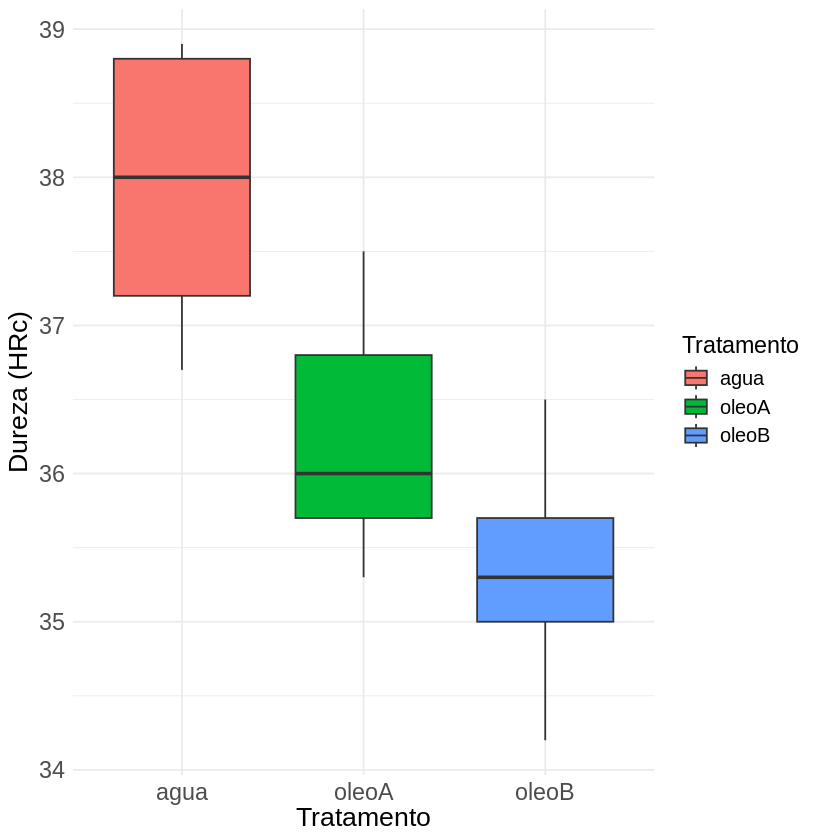

In [ ]:
library(ggplot2)

ggplot(dados, aes(x = grupo, y = valor, fill = grupo)) +
  geom_boxplot() +
  labs(
    x = "Tratamento",
    y = "Dureza (HRc)",
    fill = "Tratamento"
  ) +
  theme_minimal() +
  theme(
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12)
  )

Os gráficos de *boxplot* apresentados acima indicam que a dispersão dos dados é semelhante entre todos os tratamentos. No entanto, observa-se evidência de diferenças nos valores de dureza entre eles.

Em particular, os resultados sugerem que o tratamento realizado em `agua` apresenta, em geral, valores de dureza mais elevados. Em seguida, aparecem os materiais tratados com `oleoA`, que apresentam dureza intermediária. Por fim, os menores valores de dureza são observados no tratamento realizado com `oleoB`.

##Pressupostos da ANOVA
Antes de aplicar a ANOVA, precisamos verificar alguns pressupostos importantes. Esses pressupostos garantem que o teste estatístico produza resultados confiáveis.

Os principais são:

1. **Normalidade dos resíduos**: Os resíduos do modelo (diferença entre valores observados e valores estimados) devem seguir aproximadamente uma distribuição normal. Esse pressuposto pode ser avaliado usando o *Shapiro–Wilk test* ou observando a distribuição dos dados.

2. **Homogeneidade das variâncias**: Os grupos comparados devem ter variâncias semelhantes. Uma forma comum de verificar isso é usando o *Levene's Test* ou verificando a homocedasticidade dos resíduos.

3. **Independência das observações**: As medições devem ser independentes entre si. Em experimentos industriais isso geralmente é garantido quando as peças são produzidas e medidas separadamente. Esse pressuposto pode ser avaliado por meio do *Durbin-Watson test* ou verificando a aleatóriedade do gráfico dos resíduos *vs.* ordem da coleta dos dados.

Se esses pressupostos forem razoavelmente atendidos, a aplicação da ANOVA é apropriada.

Antes de tudo devemos ajustar um modelo de regressão simples para variáveis categóricas aos dados:

$$ y_{ij}=\mu+\sum_{j=oleoA,oleoB}^{} \tau_{j}\times I_{ij}+\epsilon_{ij},$$

onde $\mu$ é a média de dureza do tratameto com `agua`, $\tau_{j}$ é a diferença da média do tratamento $j$ em relação a média de referência (`agua`), $I_{ij}$ é uma variável indicadora e $\epsilon_{ij}$ é o erro aleatório.

No R o ajuste é feito por meio da seguinte programação:

In [ ]:
# Ajuste do modelo linear
modelo <- lm(valor ~ grupo, data = dados)

# Visualizando os coeficientes estimados
summary(modelo)

# Carregando os residuos em uma variavel
res <- residuals(modelo)


Call:
lm(formula = valor ~ grupo, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.28889 -0.65000  0.01111  0.63889  1.28889 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  37.9889     0.2585 146.960  < 2e-16 ***
grupooleoA   -1.7778     0.3656  -4.863 5.88e-05 ***
grupooleoB   -2.7111     0.3656  -7.416 1.17e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7755 on 24 degrees of freedom
Multiple R-squared:  0.7029,	Adjusted R-squared:  0.6781 
F-statistic: 28.39 on 2 and 24 DF,  p-value: 4.732e-07


O modelo confirma o que foi visualizado no *boxplot* e na média dos tratamentos, ao revelar que a média da dureza com tratamento feito com `agua` é de $37.9889$. Em seguida, o modelo mostra que média da dureza do tratamento feito com `oleoA` é de $37.9889-1.7778=36.2111$ e a média da dureza do tratamento feito com `oleoB` é de $37.9889-2.7111=35.2778$.

Com os resíduos, podemos aplicar o *Teste de Shapiro–Wilk* para verificar a normalidade. O teste de hipótese é:

> **H₀**: os dados seguem uma distribuição normal.

> **H₁**: os dados não seguem uma distribuição normal.

No R, o código para aplicar esse teste é:

In [ ]:
shapiro.test(res)


	Shapiro-Wilk normality test

data:  res
W = 0.9613, p-value = 0.3954


Ao nível de significância de $5\%$, não rejeitamos a hipótese nula, isto é, os resíduos apresentam evidências de que são oriundos de uma distribuição normal.

Uma outra forma de verificar a normalidade é utilizando o *Q-Q Plot*. O *Q-Q Plot* (*Quantile–Quantile Plot*) é um gráfico diagnóstico usado para verificar se os dados (ou resíduos de um modelo) seguem uma determinada distribuição teórica, geralmente a distribuição normal.

No R, isso pode ser feito da seguinte forma:

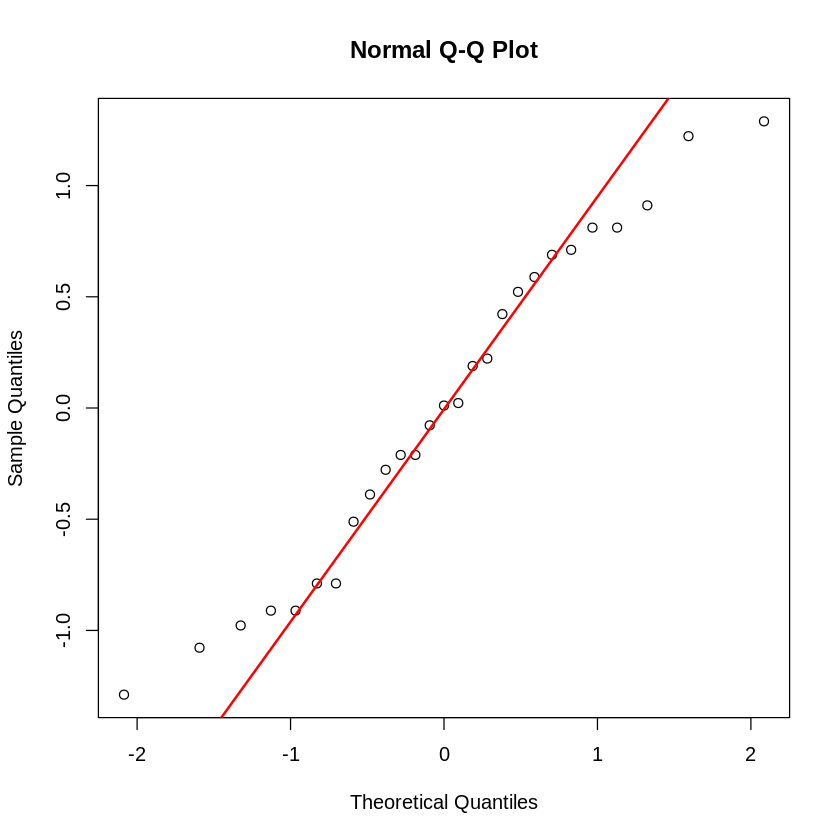

In [ ]:
qqnorm(res)
qqline(res, col = "red", lwd = 2)

Acima, o gráfico *Q-Q Plot* dos resíduos indica que os pontos estão aproximadamente alinhados com a reta de referência, sugerindo que a suposição de normalidade é plausível. Os pontos que se distanciam da reta pode ser melhor estudados na *Análise de Resíduos* e podem indicar, por exemplo, *outliers*.

Para verificar a homogeneidade das variâncias podemos verificar a homocedasticidade dos resíduos. A lógica é que, se o modelo está adequado, os resíduos devem apresentar variância aproximadamente constante para todos os tratamentos.

No R, podemos construir o gráfico dos resíduos com os valores coletados por meio da seguinte programação:

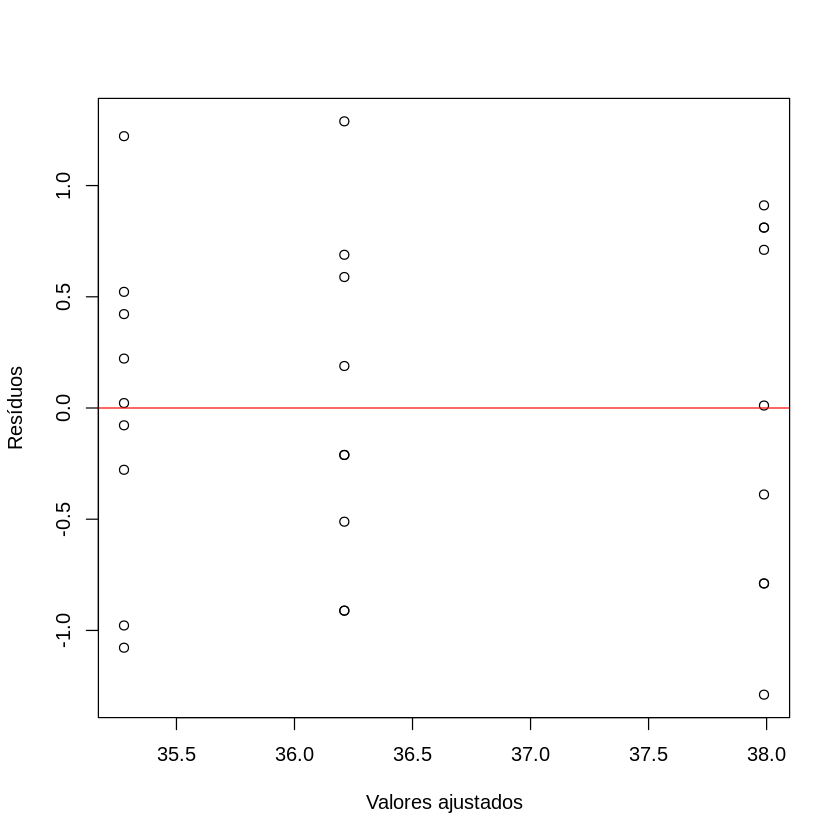

In [ ]:
plot(fitted(modelo), res,
     xlab = "Valores ajustados",
     ylab = "Resíduos")
abline(h = 0, col = "red")

A homogeneidade das variâncias dos dados foi avaliada por meio da análise gráfica dos resíduos por tratamento, não sendo observadas diferenças relevantes na dispersão, indicando que o pressuposto de homocedasticidade é razoável.

Já o pressuposto da independência dos dados pode ser verificado por meio do delineamento experimental ou por meio do gráfico dos resíduos *vs.* a ordem de coleta dos dados.

No R, podemos construir esse gráfico por meio do seguinte código:

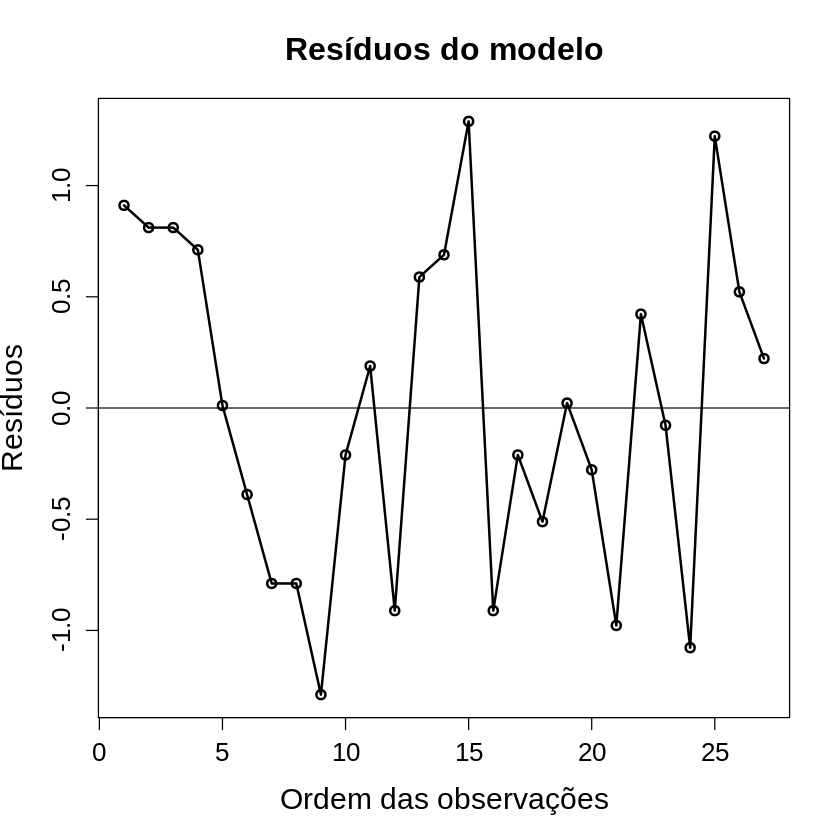

In [ ]:
plot(res,
     type = "o",
     xlab = "Ordem das observações",
     ylab = "Resíduos",
     main = "Resíduos do modelo",
     cex.lab = 1.5,
     cex.axis = 1.3,
     cex.main = 1.6,
     lwd = 2)
     abline(h=0)

Como não há uma tendência clara nos resíduos, os dados apresentam evidências de independência.

## Ajustando a ANOVA

A ANOVA foi aplicada para verificar se o **tipo de fluido** (`agua`, `oleoA`, `oleoB`) influencia na **dureza das peças de aço**. O modelo ajustado foi

$$
Y_{ij} = \mu + \tau_i + \varepsilon_{ij}
$$

onde:

* $Y_{ij}$ representa a dureza observada;
* $\mu$ é a média geral;
* $\tau_i$ é o efeito do $i$-ésimo tratamento;
* $\varepsilon_{ij}$ é o erro aleatório.

As hipóteses testadas são:


> **H₀**: $\mu_{agua} = \mu_{oleoA} = \mu_{oleoB}$

> **H₁**: pelo menos uma das médias é diferente

No R, podemos ajustar a ANOVA por meio da seguinte programação:

In [ ]:
# Realizar a Análise de Variância (ANOVA)
modelo_anova <- aov(valor ~ grupo, data = dados)

# Resumo da ANOVA
summary(modelo_anova)

            Df Sum Sq Mean Sq F value   Pr(>F)    
grupo        2  34.15  17.073   28.39 4.73e-07 ***
Residuals   24  14.43   0.601                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

A intepretação dessa tabela é:

### Graus de liberdade (Df)

* **grupo = 2**: corresponde ao número de tratamentos menos um
  $$
  3 - 1 = 2
  $$

* **resíduos = 24**: corresponde ao total de observações menos o número de tratamentos
  $$
  27 - 3 = 24
  $$

### Soma de quadrados (Sum Sq)

* **34.15**: variabilidade explicada pelos tratamentos (diferença entre as médias dos grupos).
* **14.43**: variabilidade residual, ou seja, a variabilidade dentro dos tratamentos.

A soma total da variabilidade é

$$
34.15 + 14.43 = 48.58
$$

### Quadrado médio (Mean Sq)

O quadrado médio é calculado dividindo a soma de quadrados pelos graus de liberdade.

Para os tratamentos:

$$
MS_{grupo} = \frac{34.15}{2} = 17.073
$$

Para os resíduos:

$$
MS_{res} = \frac{14.43}{24} = 0.601
$$

### Estatística F

A estatística F compara a variabilidade entre os tratamentos com a variabilidade residual:

$$
F = \frac{MS_{grupo}}{MS_{res}}
$$

$$
F = \frac{17.073}{0.601} = 28.39
$$

Um valor elevado de $F$ indica que a variabilidade entre os tratamentos é muito maior que a variabilidade dentro dos tratamentos.

### Valor-p

O valor-p associado à estatística F foi

$$
p = 4.73 \times 10^{-7}
$$

Como

$$
p < 0.05
$$

rejeita-se a hipótese nula.

### Conclusão

Há evidências estatísticas de que **o tipo de fluido influencia a dureza do ferro**. Portanto, pelo menos um dos tratamentos (`agua`, `oleoA` ou `oleoB`) apresenta média de dureza diferente, conforme verificado antes no *boxplot* das amostras.

Para identificar **quais tratamentos diferem entre si**, deve-se aplicar um teste de comparações múltiplas, como o **teste de Tukey**.
